# Simulação Computacional: Efeitos da Frequência de Amostragem

Nesta etapa, investigamos o processo de amostragem de um sinal contínuo, analisando como diferentes valores de frequência de amostragem ($f_s$) afetam a representação discreta resultante. 

O sinal base utilizado continua a ser o modelo da rede elétrica brasileira ($60\,\text{Hz}$ com $179{,}6\,\text{V}$ de pico). Três cenários distintos serão simulados:
1. **$f_s = 480\,\text{Hz}$**: Alta resolução (8 amostras por ciclo, respeitando com folga o critério de Nyquist).
2. **$f_s = 120\,\text{Hz}$**: Limite teórico de Nyquist (exatamente 2 amostras por ciclo).
3. **$f_s = 70\,\text{Hz}$**: Subamostragem crítica (abaixo de Nyquist, evidenciando distorção visual e perda de informação).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração de estilo (padrão acadêmico)
sns.set_theme(
    context="paper", style="ticks", palette="colorblind", font="serif",
    rc={
        "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
        "axes.grid": True, "grid.linestyle": "--", "grid.alpha": 0.6,
        "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
        "mathtext.fontset": "cm",
    },
)

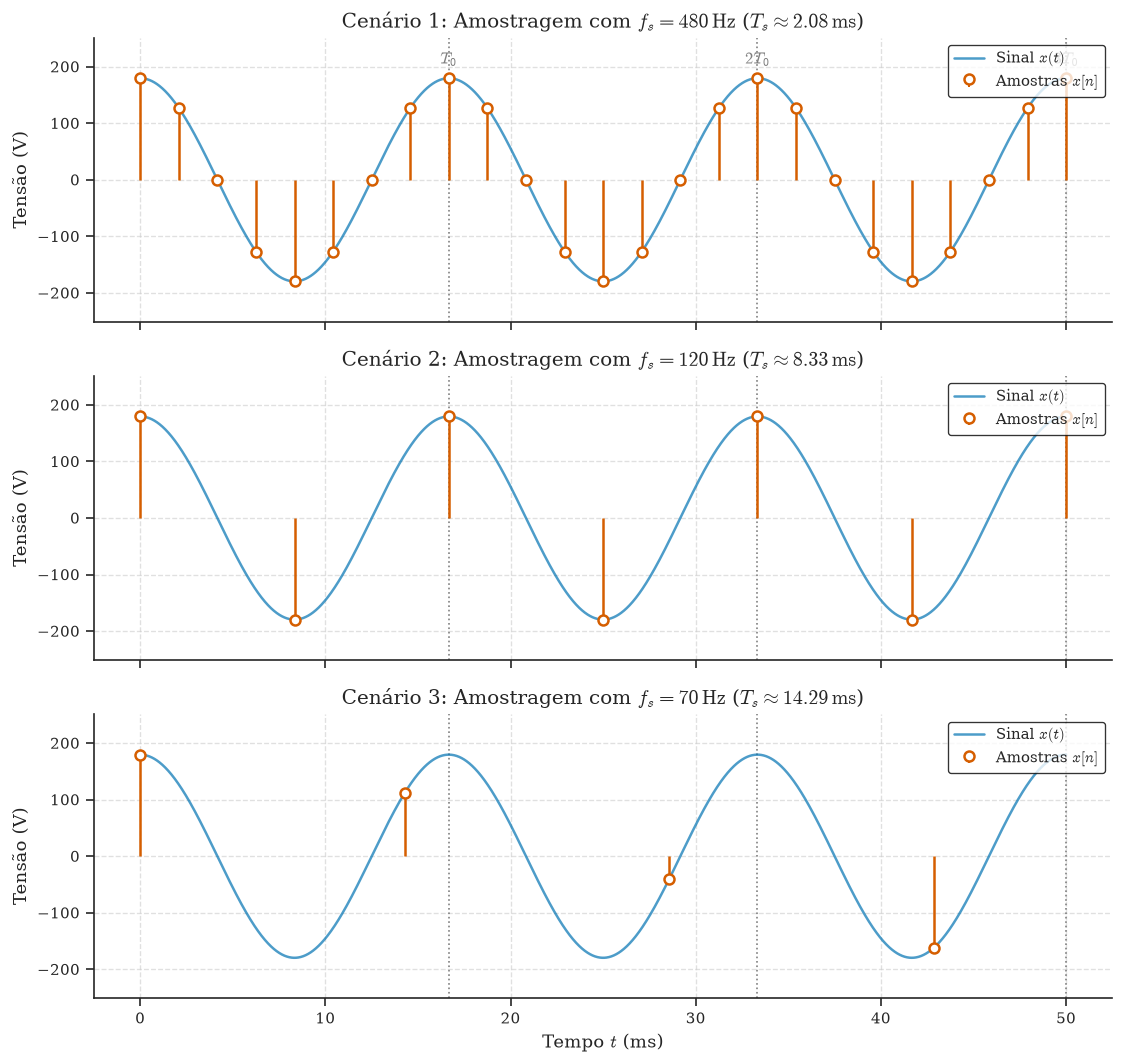

In [2]:
# Parâmetros do Sinal Contínuo
f0 = 60.0
A = 179.6
T0 = 1.0 / f0
t_end = 3.0 * T0 # Simulando 3 ciclos completos
ms_fator = 1000.0

# Eixo de tempo contínuo (alta resolução)
t_cont = np.linspace(0, t_end, 3000)
x_cont = A * np.cos(2.0 * np.pi * f0 * t_cont)

# Frequências de amostragem a serem investigadas
fs_list = [480.0, 120.0, 70.0]

# Configuração da Figura com 3 subgráficos (linhas)
fig, axes = plt.subplots(3, 1, figsize=(9.5, 9), sharex=True)
cores = sns.color_palette("colorblind")

for i, fs in enumerate(fs_list):
    ax = axes[i]
    Ts = 1.0 / fs
    
    # Geração do Sinal Discreto
    n_amostras = np.arange(0, int(np.floor(t_end * fs)) + 1)
    t_disc = n_amostras * Ts
    x_disc = A * np.cos(2.0 * np.pi * f0 * t_disc)
    
    # Plotagem
    ax.plot(t_cont * ms_fator, x_cont, color=cores[0], linewidth=1.5, alpha=0.7, label=r"Sinal $x(t)$", zorder=2)
    markerline, stemlines, baseline = ax.stem(
        t_disc * ms_fator, x_disc, linefmt="-", markerfmt="o", basefmt=" ", label=r"Amostras $x[n]$"
    )
    plt.setp(stemlines, color=cores[3], linewidth=1.5, zorder=3)
    plt.setp(markerline, color=cores[3], markersize=6, markerfacecolor="white", markeredgewidth=1.5, zorder=4)
    
    # Marcações de ciclo
    for k in range(1, 4):
        instante = k * T0 * ms_fator
        ax.axvline(instante, color="gray", linewidth=1.0, linestyle=":", zorder=1)
        if i == 0: # Coloca os rótulos de ciclo apenas no primeiro gráfico
            rotulo = rf"${k}T_0$" if k > 1 else r"$T_0$"
            ax.text(instante, A * 1.1, rotulo, ha="center", va="bottom", fontsize=10, color="gray")

    # Formatação do eixo
    ax.set_title(rf"Cenário {i+1}: Amostragem com $f_s = {fs:.0f}\,\mathrm{{Hz}}$ ($T_s \approx {Ts*1000:.2f}\,\mathrm{{ms}}$)")
    ax.set_ylabel(r"Tensão (V)")
    ax.set_ylim(-A * 1.4, A * 1.4)
    ax.legend(loc="upper right", frameon=True, edgecolor="black", fontsize=9)

axes[-1].set_xlabel(r"Tempo $t$ (ms)")
sns.despine(trim=False)
fig.tight_layout()

# Salvar Imagem
os.makedirs("../simulacao", exist_ok=True)
fig.savefig("../simulacao/grafico_amostragem_comparativa.png")
plt.show()

In [3]:
print("=== RESUMO NUMÉRICO DAS AMOSTRAGENS ===")
for fs in fs_list:
    Ts = 1.0 / fs
    amostras_por_ciclo = fs / f0
    print(f"Frequência fs: {fs:3.0f} Hz | Período Ts: {Ts*1000:5.2f} ms | Amostras por ciclo: {amostras_por_ciclo:.2f}")
print("=======================================")

=== RESUMO NUMÉRICO DAS AMOSTRAGENS ===
Frequência fs: 480 Hz | Período Ts:  2.08 ms | Amostras por ciclo: 8.00
Frequência fs: 120 Hz | Período Ts:  8.33 ms | Amostras por ciclo: 2.00
Frequência fs:  70 Hz | Período Ts: 14.29 ms | Amostras por ciclo: 1.17
